# Mixer Verification

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
import rfmodel.rf.registry

cfg = load_yaml(r".\PLL_mixer.yaml")
pipe = pipeline_from_config(cfg)

TypeError: MixerParams.__init__() got an unexpected keyword argument 'iq_amp_imb_db'

In [ ]:
mixer = pipe.get("mixer_and_pll")
mixer.pll = None
mixer.params.mixer_ideal = True

In [ ]:
fs = 10e6
N = 2**14
t = np.arange(N) / fs

x = (
    np.exp(1j * 2*np.pi*100e3*t) +
    0.7 * np.exp(1j * 2*np.pi*300e3*t)
)

sig_in = Signal(x=x, fs_hz=fs, fc_hz=0, meta={})


In [ ]:
# --- run through mixer only ---
sig_out = mixer(sig_in)
y = sig_out.x

In [ ]:
# --- 1. Power preservation test ---
Pin = np.mean(np.abs(x)**2)
Pout = np.mean(np.abs(y)**2)

print("Input power:", Pin)
print("Output power:", Pout)
print("Power ratio (Pout/Pin):", Pout / Pin)

# ideal expectation: ~1.0
assert np.isclose(Pout / Pin, 1.0, atol=1e-6), "Power not preserved → not ideal"

Input power: 1.4894464584711389
Output power: 1.4894464584711389
Power ratio (Pout/Pin): 1.0


## Plotting Ideal Mixer Output

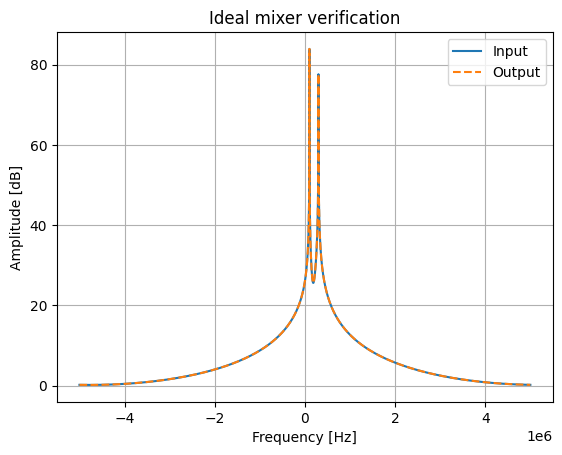

In [ ]:
X = np.fft.fftshift(np.fft.fft(x))
Y = np.fft.fftshift(np.fft.fft(y))
f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

plt.figure()
plt.plot(f, 20*np.log10(np.abs(X)+1e-12), label="Input")
plt.plot(f, 20*np.log10(np.abs(Y)+1e-12), "--", label="Output")
plt.legend()
plt.grid()
plt.title("Ideal mixer verification")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dB]")
plt.show()

## Intermodulation Test

In [ ]:
from scipy.signal import hilbert
from rfmodel.core.units import dbm_to_w, w_to_dbm, db_to_linear
from rfmodel.meas.spectrum_analyser import spectrum_analyser

mixer = pipe.get("mixer_and_pll")
mixer.pll = None
mixer.params.mixer_ideal = False
nf_backup = mixer.params.nf_db
mixer.params.nf_db = 0

fs = 5_000_000
t = np.arange(0, 2e-3, 1/fs)

fc = 1e6
f_offset1 = 50_000
f_offset2 = 120_000

# Real two-tone RF signal → complex envelope via Hilbert
rf = np.cos(2*np.pi*(fc + f_offset1)*t) + np.cos(2*np.pi*(fc + f_offset2)*t)
rf_analytic = hilbert(rf)
complex_envelope = rf_analytic * np.exp(-1j * 2*np.pi*fc*t)

combined_two_tone = Signal(
    x=complex_envelope,
    fs_hz=fs,
    fc_hz=fc,
    meta={"name": "two-tone IM3 test"},
)

# Power sweep
Pin0_W   = np.mean(np.abs(combined_two_tone.x)**2) / 4   # per-tone real power
Pin0_dBm = w_to_dbm(Pin0_W)

Pin_dBm_sweep  = np.linspace(-30, 0, 1000)
scale_factors  = 10 ** ((Pin_dBm_sweep - Pin0_dBm) / 20.0)

target_f_im3_1 = 2*f_offset1 - f_offset2
target_f_im3_2 = 2*f_offset2 - f_offset1

Pout_fund_list = []
Pout_IM3_list  = []

for k in scale_factors:
    sweep_sig = combined_two_tone.copy_with(x=k * combined_two_tone.x)
    sig_out, _ = pipe.run(sweep_sig)

    S_out, freqs = spectrum_analyser(sig_out.x, fs)

    idx_fund_1 = np.argmin(np.abs(freqs - f_offset1))
    idx_fund_2 = np.argmin(np.abs(freqs - f_offset2))
    idx_im3_1  = np.argmin(np.abs(freqs - target_f_im3_1))
    idx_im3_2  = np.argmin(np.abs(freqs - target_f_im3_2))

    Pout_fund_list.append(w_to_dbm(S_out[idx_fund_1] + S_out[idx_fund_2]))
    Pout_IM3_list.append(w_to_dbm(S_out[idx_im3_1]  + S_out[idx_im3_2]))

Pout_fund_dbm = np.array(Pout_fund_list)
Pout_IM3_dbm  = np.array(Pout_IM3_list)

plt.figure(figsize=(8, 5))
plt.plot(Pin_dBm_sweep, Pout_fund_dbm, label="Fundamental (sum)")
plt.plot(Pin_dBm_sweep, Pout_IM3_dbm,  label="IM3 (sum)")
plt.xlabel("Pin per tone, real (dBm)")
plt.ylabel("Pout (dBm)")
plt.title("Two-tone IM3 sweep")
plt.grid(True)
plt.legend()
plt.show()

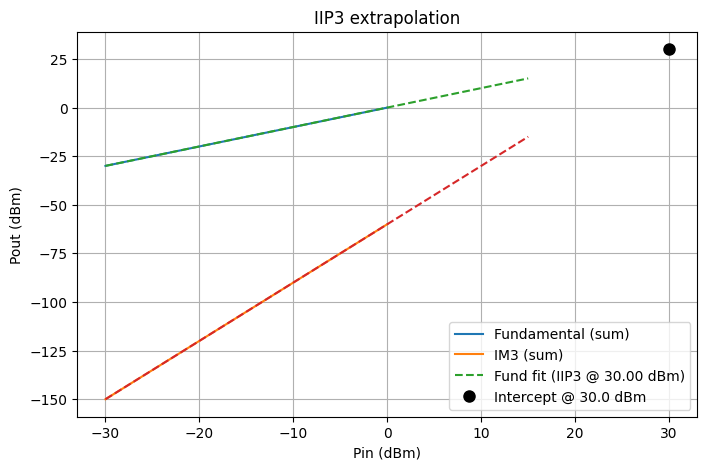

Fundamental slope: 1.000 dB/dB  (expected 1.0)
IM3 slope:         3.000 dB/dB  (expected 3.0)
IIP3 measured:     30.00 dBm
IIP3 configured:   30.0 dBm
Error:             -0.00 dB


In [ ]:
fit_min, fit_max = -30, -20
mask = (Pin_dBm_sweep >= fit_min) & (Pin_dBm_sweep <= fit_max)

m_f, b_f = np.polyfit(Pin_dBm_sweep[mask], Pout_fund_dbm[mask], 1)
m_i, b_i = np.polyfit(Pin_dBm_sweep[mask], Pout_IM3_dbm[mask],  1)

x_cross = (b_i - b_f) / (m_f - m_i)
y_cross = m_f * x_cross + b_f

x_ext = np.linspace(np.min(Pin_dBm_sweep), np.max(Pin_dBm_sweep) + 15, 400)

plt.figure(figsize=(8, 5))
plt.plot(Pin_dBm_sweep, Pout_fund_dbm, label="Fundamental (sum)")
plt.plot(Pin_dBm_sweep, Pout_IM3_dbm,  label="IM3 (sum)")
plt.plot(x_ext, m_f*x_ext + b_f, '--', label=f'Fund fit (IIP3 @ {x_cross:.2f} dBm)')
plt.plot(x_ext, m_i*x_ext + b_i, '--')
plt.plot(x_cross, y_cross, 'ko', markersize=8, label=f'Intercept @ {x_cross:.1f} dBm')
plt.xlabel("Pin (dBm)")
plt.ylabel("Pout (dBm)")
plt.title("IIP3 extrapolation")
plt.grid(True)
plt.legend()
plt.show()

print(f"Fundamental slope: {m_f:.3f} dB/dB  (expected 1.0)")
print(f"IM3 slope:         {m_i:.3f} dB/dB  (expected 3.0)")
print(f"IIP3 measured:     {x_cross:.2f} dBm")
print(f"IIP3 configured:   {mixer.params.iip3_dbm} dBm")
print(f"Error:             {x_cross - mixer.params.iip3_dbm:.2f} dB")

## Noise Figure Test

=== Noise Figure Test ===
Output noise power: -105.00 dBm
NF measured:        4.99 dB
NF configured:      5.0 dB


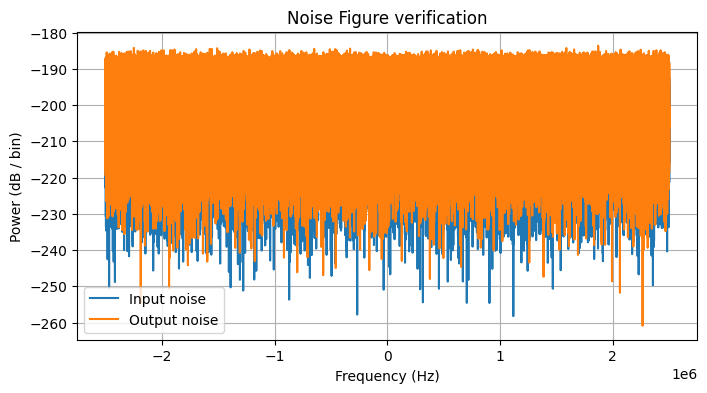

In [ ]:
mixer.pll = None
mixer.params.mixer_ideal = False
mixer.params.nf_db = nf_backup

kB  = 1.380649e-23
T   = mixer.params.temp_k
B   = fs / 2.0
G   = db_to_linear(mixer.params.gain_db)
dur = 0.2
N   = int(fs * dur)

# Thermal noise input
Pn_in = kB * T * B
sigma = np.sqrt(Pn_in / 2)

rng   = np.random.default_rng(0)
x_in  = sigma * (rng.normal(size=N) + 1j * rng.normal(size=N))
sig_in = Signal(x=x_in, fs_hz=fs, fc_hz=0, meta={})

sig_out, taps = pipe.run(sig_in, taps=["mixer_and_pll"])
x_out = taps["mixer_and_pll"].x

Pnout   = np.mean(np.abs(x_out)**2)
F       = Pnout / (G * Pn_in)
NF_db   = 10 * np.log10(F)

print(f"=== Noise Figure Test ===")
print(f"Output noise power: {10*np.log10(Pnout/1e-3):.2f} dBm")
print(f"NF measured:        {NF_db:.2f} dB")
print(f"NF configured:      {mixer.params.nf_db} dB")

S_in,  freqs = spectrum_analyser(x_in,  fs)
S_out, _     = spectrum_analyser(x_out, fs)

plt.figure(figsize=(8, 4))
plt.plot(freqs, 10*np.log10(np.maximum(S_in,  1e-30)), label="Input noise")
plt.plot(freqs, 10*np.log10(np.maximum(S_out, 1e-30)), label="Output noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB / bin)")
plt.title("Noise Figure verification")
plt.legend()
plt.grid(True)
plt.show()